In [1]:
import os
from astropy.io import fits
from astropy.table import Table

# Define your data directory
base_dir = r"C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\value_added_catalog"

# List of your specific files
files = [
    "dr8_final_vac_flag_parameter.fits",
#    "LAMOST-APOGEE.fits",
#    "LAMOST-PASTEL.fits",
#    "LGMWAS.fits"
]

for filename in files:
    path = os.path.join(base_dir, filename)
    print(f"\n{'='*40}")
    print(f"FILE: {filename}")
    print(f"{'='*40}")
    
    try:
        # Open file (memmap=True prevents loading massive files entirely into RAM)
        with fits.open(path, memmap=True) as hdul:
            # Usually data is in extension 1, but we check info first
            hdul.info() 
            
            # Load the table from the first extension with data
            # (Ext 0 is usually empty primary header, Ext 1 is table)
            data = Table(hdul[1].data)
            
            print(f"\nSHAPE: {len(data)} rows, {len(data.colnames)} columns")
            
            print(f"\nALL COLUMNS: {data.colnames}")
            
            print(f"\nFIRST 5 ROWS:")
            # displaying as standard text for readability
            data[:5].pprint(max_width=-1, max_lines=10) 
            
    except Exception as e:
        print(f"Error reading {filename}: {e}")


FILE: dr8_final_vac_flag_parameter.fits
Filename: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\value_added_catalog\dr8_final_vac_flag_parameter.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (10,)   int64   
  1                1 BinTableHDU    232   7109030R x 112C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 19A, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   

SHAPE: 7109030 rows, 112 columns

ALL COLUMNS: ['obsid', 'ra_obs', 'dec_obs', 'FEH_APOGEE', 'MH_APOGEE', 'CH_APOGEE', 'NH_APOGEE', 'CFE_APOGEE', 'NFE_APOGEE', 'AFE_APOGEE', 'LOGG_APOGEE', 'TEFF_PASTEL', 'LOGG_PASTEL', 'FEH_PASTEL', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_B

In [2]:
import numpy as np
from astropy.table import Table

# Update this path to your actual file location
file_path = r"C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\value_added_catalog\dr8_final_vac_flag_parameter.fits"

print("Loading Data...")
# Read columns relevant to selection to save memory
cols_to_keep = [
    'obsid', 'ra_obs', 'dec_obs', 
    'TEFF_PASTEL', 'LOGG_PASTEL', 'FEH_PASTEL',
    'snrg', 'uqflag', 
    'flag_teff_pastel', 'flag_logg_pastel'
]

try:
    # Read only specific columns to be fast
    tbl = Table.read(file_path, format='fits', memmap=True)
    # Filter to just the columns we need for now (optional, but good for RAM)
    tbl = tbl[cols_to_keep]
    print(f"Loaded {len(tbl)} rows.")
except Exception as e:
    print(f"Failed to load: {e}")

Loading Data...
Loaded 7109030 rows.


Chunk 2: Apply Physics & Quality Cuts

In [3]:
def select_cool_dwarfs(data_table):
    """
    Filters for high-quality K & M dwarfs based on Wang et al. (2022) flags.
    """
    print(f"Starting Rows: {len(data_table)}")
    
    # --- 1. Physics Cuts (Dwarfs) ---
    # Logg > 4.0 removes Giants (approximate but effective for bulk selection)
    mask_dwarf = data_table['LOGG_PASTEL'] > 4.0
    
    # Teff < 5300 K selects K and M types (Sun is 5777 K)
    # We also set a lower bound > 0 to remove NaNs/Errors
    mask_cool = (data_table['TEFF_PASTEL'] < 5300) & (data_table['TEFF_PASTEL'] > 2000)
    
    # --- 2. Quality Cuts (Paper Recommendations) ---
    # SNR > 10 is the dataset's definition of "valid" 
    mask_snr = data_table['snrg'] > 10
    
    # Flag == 0 means "Reliable / Inside Training Grid" 
    mask_quality = (data_table['flag_teff_pastel'] == 0) & (data_table['flag_logg_pastel'] == 0)
    
    # Unique sources only
    mask_unique = data_table['uqflag'] == 1
    
    # Combine Masks
    final_mask = mask_dwarf & mask_cool & mask_snr & mask_quality & mask_unique
    
    # Apply Selection
    selected_data = data_table[final_mask]
    
    print(f"--- Survival Statistics ---")
    print(f"Pass Dwarfs (logg>4): {np.sum(mask_dwarf)}")
    print(f"Pass Cool (Teff<5300): {np.sum(mask_cool)}")
    print(f"Pass SNR (>10):       {np.sum(mask_snr)}")
    print(f"Pass Flags (=0):      {np.sum(mask_quality)}")
    print(f"FINAL COUNT:          {len(selected_data)}")
    
    return selected_data

# Run the selection
clean_dwarfs = select_cool_dwarfs(tbl)

Starting Rows: 7109030
--- Survival Statistics ---
Pass Dwarfs (logg>4): 4398280
Pass Cool (Teff<5300): 2567875
Pass SNR (>10):       7106582
Pass Flags (=0):      6701796
FINAL COUNT:          872105


Left Join

In [4]:
import pandas as pd
from astropy.table import Table

# 1. Load the M-Dwarf CSV (The "Left" Table)
# This is your target list
df_target = pd.read_csv("C:\\git_repo\\cool-dwarf_stellar_parameter_inference_from_survey_data\\data\\LAMOST_dM0-9.csv")

# 2. Load the VAC FITS (The "Right" Table)
# We convert it to a pandas DataFrame for easier merging
vac_table = Table.read("C:\\git_repo\\cool-dwarf_stellar_parameter_inference_from_survey_data\\data\\value_added_catalog\\dr8_final_vac_flag_parameter.fits", format='fits', memmap=True)
# Select only useful columns from VAC to save memory and avoid clutter
# We MUST keep 'obsid' to perform the match
vac_cols = ['obsid', 'TEFF_PASTEL', 'LOGG_PASTEL', 'FEH_PASTEL', 
            'A_GG', 'A_BP', 'A_RP', # From Gaia EDR3 (Space-based parallax & photometry).
            'A_J', 'A_H', 'A_KS', # From 2MASS (Infrared survey)
            'A_W1', 'A_W2', # From WISE (Mid-infrared space telescope)
            'A_GSD', 'A_RSD', 'A_ISD', # From SDSS (Optical survey).
            'A_BAP', 'A_VAP', # From APASS (Photometric survey).
            'snrg', 'uqflag', 'flag_teff_pastel']
df_vac = vac_table[vac_cols].to_pandas()

# 3. Clean the Keys
# Sometimes obsid is read as a float (1234.0) vs integer (1234). We force them to match.
df_target['obsid'] = df_target['obsid'].astype(int)
df_vac['obsid'] = df_vac['obsid'].astype(int)

# 4. Perform the Merge (Left Join)
# "on='obsid'" tells Python to match rows where this ID is identical
df_merged = pd.merge(df_target, df_vac, on='obsid', how='left')

# 5. Sanity Check
print(f"Original M-Dwarf Count: {len(df_target)}")
print(f"Merged Dataset Count:   {len(df_merged)}")
print(f"Matches Found:          {df_merged['TEFF_PASTEL'].notnull().sum()}")

# Show a sample
print(df_merged[['obsid', 'subclass', 'mag_ps_r', 'A_RSD', 'TEFF_PASTEL']].head())

Original M-Dwarf Count: 179930
Merged Dataset Count:   179930
Matches Found:          50317
       obsid subclass   mag_ps_r     A_RSD  TEFF_PASTEL
0   66515149      dM3  15.610000       NaN          NaN
1   66614201      dM2  15.762100       NaN          NaN
2   77207087      dM1  15.585700  5.318371  4529.806152
3  104803004      dM4  15.416700  5.181851  4691.344727
4  105904178      dM1  17.615999       NaN          NaN


In [5]:
print(df_merged.columns.tolist())

['obsid', 'snrr', 'snri', 'class', 'subclass', 'z', 'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', 'gaia_source_id', 'gaia_g_mean_mag', 'ra', 'dec', 'teff', 'rv', 'logg', 'feh', 'TEFF_PASTEL', 'LOGG_PASTEL', 'FEH_PASTEL', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_GSD', 'A_RSD', 'A_ISD', 'A_BAP', 'A_VAP', 'snrg', 'uqflag', 'flag_teff_pastel']


Dropping irrelevant columns

In [6]:
# Create a clean copy to work with
df_clean = df_merged.copy()

# List of columns to drop as requested
cols_to_drop = ['snrr', 'snri', 'z', 'ra', 'dec', 'feh', 'rv', 'snrg', 'class']

# Drop them if they exist (errors='ignore' prevents crashing if you run this cell twice)
df_clean.drop(columns=cols_to_drop, errors='ignore', inplace=True)

print(f"Columns removed: {cols_to_drop}")
print(f"Current Shape: {df_clean.shape}")
print(f"Remaining Columns: {list(df_clean.columns)}")

Columns removed: ['snrr', 'snri', 'z', 'ra', 'dec', 'feh', 'rv', 'snrg', 'class']
Current Shape: (179930, 29)
Remaining Columns: ['obsid', 'subclass', 'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', 'gaia_source_id', 'gaia_g_mean_mag', 'teff', 'logg', 'TEFF_PASTEL', 'LOGG_PASTEL', 'FEH_PASTEL', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_GSD', 'A_RSD', 'A_ISD', 'A_BAP', 'A_VAP', 'uqflag', 'flag_teff_pastel']


Replace Sentry Values

In [7]:
# 1. Replace Sentry Values (-9999) with NaN in the pipeline teff
# We use .replace() to swap the specific error code for a real null value
df_clean['teff'] = df_clean['teff'].replace(-9999, np.nan)

# 2. Rename columns to be explicit
# 'teff' -> 'teff_pipeline' (The standard LAMOST pipeline result)
# 'TEFF_PASTEL' -> 'teff_vac' (The Wang et al. Value-Added Catalog result)
rename_map = {
    'teff': 'teff_pipeline',
    'TEFF_PASTEL': 'teff_vac'
}
df_clean.rename(columns=rename_map, inplace=True)

print("Renaming complete. New columns:", list(df_clean.columns))

Renaming complete. New columns: ['obsid', 'subclass', 'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', 'gaia_source_id', 'gaia_g_mean_mag', 'teff_pipeline', 'logg', 'teff_vac', 'LOGG_PASTEL', 'FEH_PASTEL', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_GSD', 'A_RSD', 'A_ISD', 'A_BAP', 'A_VAP', 'uqflag', 'flag_teff_pastel']


Chunk 2: Apply Quality Cuts (Flags)

In [8]:
# Print count before filtering
print(f"Rows before flag cuts: {len(df_clean)}")

# 1. Filter for Unique Sources (uqflag == 1)
# (not used this filter) flag_teff_pastel == 1: not confident Teff
# We assume 'flag_teff_pastel' exists. If you renamed it, update the name here.
quality_mask = (df_clean['uqflag'] == 1)

df_quality = df_clean[quality_mask].copy()

print(f"Rows after flag cuts:  {len(df_quality)}")
print(f"Dropped {len(df_clean) - len(df_quality)} duplicate rows.")

Rows before flag cuts: 179930
Rows after flag cuts:  41362
Dropped 138568 duplicate rows.


Chunk 3: Drop Rows with ANY Missing Photometry

In [9]:
# Define the list of CRITICAL magnitude columns.
# These are the inputs your Neural Network will likely need.
# Adjust this list if you want to be less strict (e.g., remove 'A_W2' if it kills too many rows).
mag_cols = [
    'mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y', # Pan-STARRS (from your CSV)
    'A_GG', 'A_BP', 'A_RP', # From Gaia EDR3 (Space-based parallax & photometry).
    'A_J', 'A_H', 'A_KS', # From 2MASS (Infrared survey)
    'A_W1', 'A_W2', # From WISE (Mid-infrared space telescope)
    'A_GSD', 'A_RSD', 'A_ISD', # From SDSS (Optical survey).
    'A_BAP', 'A_VAP' # From APASS (Photometric survey).
]

# Ensure we also don't have missing Labels (Targets)
target_cols = ['teff_pipeline', 'teff_vac']

# Combine lists to check for NaNs
cols_to_check = mag_cols + target_cols

# Drop rows where ANY of these columns are NaN
# errors='ignore' ensures it doesn't crash if a column name is slightly wrong
existing_cols = [c for c in cols_to_check if c in df_quality.columns]
df_final = df_quality.dropna(subset=existing_cols)

print(f"Rows before NaN drop: {len(df_quality)}")
print(f"Rows after NaN drop:  {len(df_final)}")
print(f"Final dataset size:   {len(df_final)}")

# Final Sanity Check: Show the first few rows of the clean data
df_final[['obsid', 'teff_pipeline', 'teff_vac', 'mag_ps_r', 'A_J']].head()

Rows before NaN drop: 41362
Rows after NaN drop:  41362
Final dataset size:   41362


,obsid,teff_pipeline,teff_vac,mag_ps_r,A_J
2,77207087,3618.61,4529.806152,15.5857,2.928995
3,104803004,3365.84,4691.344727,15.4167,3.877683
10,120705055,3558.87,4773.159668,15.2315,3.650517
11,120711024,3786.36,4544.094727,15.4568,3.774902
13,121009103,3859.55,4485.750000,15.7096,3.322804


In [10]:
"""df_final
out_path = r"C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\LAMOST_merged_final.csv"
df_final.to_csv(out_path, index=False)"""

'df_final\nout_path = r"C:\\git_repo\\cool-dwarf_stellar_parameter_inference_from_survey_data\\data\\LAMOST_merged_final.csv"\ndf_final.to_csv(out_path, index=False)'

In [11]:
df_final.columns.tolist()

['obsid',
 'subclass',
 'mag_ps_g',
 'mag_ps_r',
 'mag_ps_i',
 'mag_ps_z',
 'mag_ps_y',
 'gaia_source_id',
 'gaia_g_mean_mag',
 'teff_pipeline',
 'logg',
 'teff_vac',
 'LOGG_PASTEL',
 'FEH_PASTEL',
 'A_GG',
 'A_BP',
 'A_RP',
 'A_J',
 'A_H',
 'A_KS',
 'A_W1',
 'A_W2',
 'A_GSD',
 'A_RSD',
 'A_ISD',
 'A_BAP',
 'A_VAP',
 'uqflag',
 'flag_teff_pastel']

In [12]:
# 0. Mask extreme temperatures
# We create a specific mask for "physically reasonable" dwarfs
# You can adjust the 10000 limit if you expect hotter stars, 
# but for K/M dwarfs, >7000 is already suspicious.
temp_mask = (
    (df_final['teff_pipeline'] < 10000) & (df_final['teff_pipeline'] > 2000) &
    (df_final['teff_vac'] < 10000) & (df_final['teff_vac'] > 2000)
)

df_test = df_final[temp_mask].copy()

print(f"Original Rows: {len(df_final)}")
print(f"Filtered Rows: {len(df_test)}")
print(f"Dropped {len(df_final) - len(df_test)} outliers.")

Original Rows: 41362
Filtered Rows: 41060
Dropped 302 outliers.


In [13]:
# Define thresholds for absolute magnitudes
# These thresholds are based on typical ranges for cool K and M dwarfs
absolute_magnitude_thresholds = {
    'A_GG': (-10, 20), 'A_BP': (-10, 20), 'A_RP': (-10, 20),
    'A_J': (-10, 20), 'A_H': (-10, 20), 'A_KS': (-10, 20),
    'A_W1': (-10, 20), 'A_W2': (-10, 20),
    'A_GSD': (-10, 20), 'A_RSD': (-10, 20), 'A_ISD': (-10, 20),
    'A_BAP': (-10, 20), 'A_VAP': (-10, 20)
}

# Identify rows with extreme absolute magnitudes
outlier_mask = None
for col, (lower, upper) in absolute_magnitude_thresholds.items():
    if col in df_final.columns:
        col_mask = (df_final[col] < lower) | (df_final[col] > upper)
        outlier_mask = col_mask if outlier_mask is None else (outlier_mask | col_mask)

# List out the rows with extreme absolute magnitudes
outliers = df_final[outlier_mask]
print("Outliers with extreme absolute magnitudes:")
print(outliers)

# Drop the rows with extreme absolute magnitudes
df_final = df_final[~outlier_mask]

print(f"Rows after removing outliers: {len(df_final)}")

Outliers with extreme absolute magnitudes:
            obsid subclass   mag_ps_g   mag_ps_r   mag_ps_i  mag_ps_z  \
1597    248805016      dM4  17.856600  16.664400  15.348100   14.7478   
2045    301408018      dM1  17.574800  16.356199  15.342600   14.8848   
3448    504101153      dM5  17.627001  16.165001  17.880699   14.4630   
3899    600403083      dM0  17.024401  15.797100  15.162300   14.8661   
3990    605404248      dM0  16.801100  15.406800  14.600000   14.1831   
...           ...      ...        ...        ...        ...       ...   
177453  556406022      dM1  14.883300  13.715900  13.222000   12.7810   
177638  592404236      dM1  17.607401  16.343700  15.505400   15.1077   
177649  593104245      dM2  16.719400  15.507600  14.525100   14.0736   
178707  768009116      dM2  17.311501  16.046101  14.950600   14.4649   
178982  815006026      dM0  16.898800  15.709000  15.104700   14.8229   

        mag_ps_y       gaia_source_id  gaia_g_mean_mag  teff_pipeline  ...  \
15

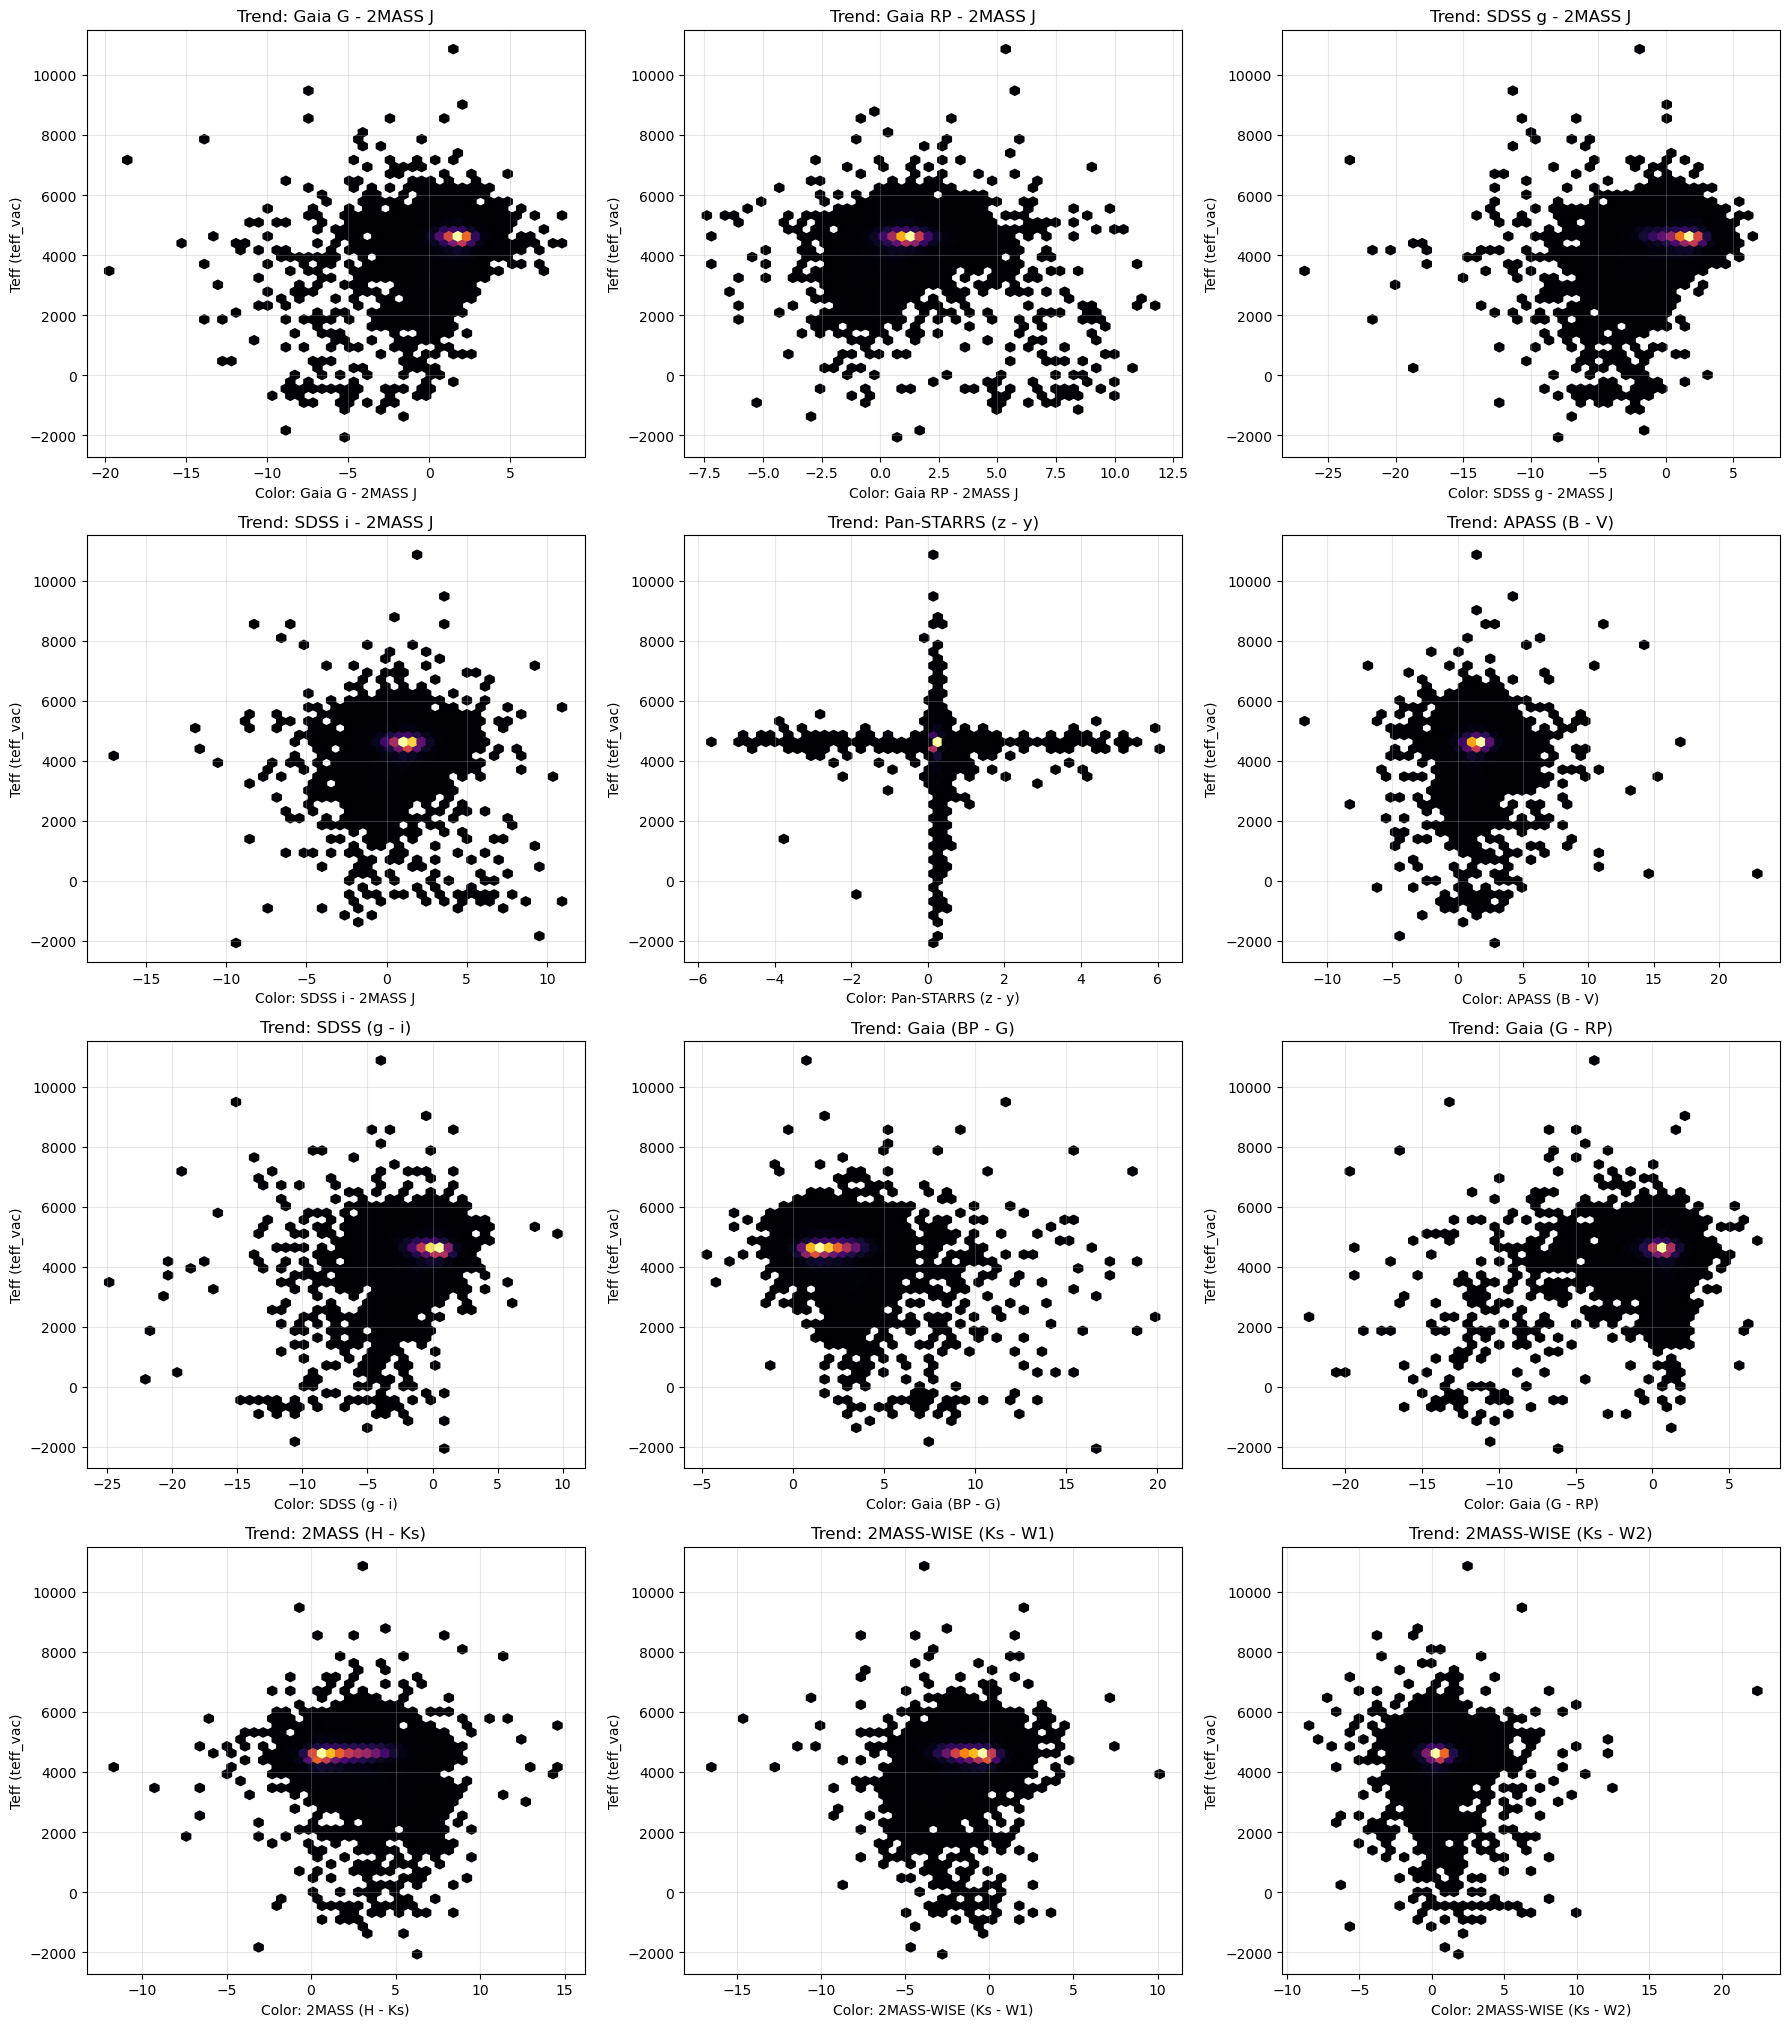

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Format: (Blue_Band_Column, Red_Band_Column, Label_Name)
# We mix Apparent (mag_ps) with Apparent, and Absolute (A_) with Absolute to be safe.
color_combinations = [
    # --- 1. Long Baseline (Visual minus Infrared) ---
    # These are often the BEST temperature indicators for M-dwarfs
    ('A_GG',  'A_J',   'Gaia G - 2MASS J'),      # Very wide baseline
    ('A_RP',  'A_J',   'Gaia RP - 2MASS J'),     # Red Optical - IR
    ('A_GSD', 'A_J',   'SDSS g - 2MASS J'),      # Deep Blue - IR
    ('A_ISD', 'A_J',   'SDSS i - 2MASS J'),      # Red Optical - IR
    
    # --- 2. Pan-STARRS (Far Red) ---
    # You checked g-r and i-z, let's check the very red end
    ('mag_ps_z', 'mag_ps_y', 'Pan-STARRS (z - y)'),
    
    # --- 3. Classic Johnson-Cousins (APASS) ---
    # B-V is the historical standard for stellar typing
    ('A_BAP', 'A_VAP', 'APASS (B - V)'),
    
    # --- 4. SDSS Optical Combos ---
    ('A_GSD', 'A_ISD', 'SDSS (g - i)'),          # Wide optical
    
    # --- 5. Gaia Internal ---
    # We looked at BP-RP, but these split the difference
    ('A_BP', 'A_GG', 'Gaia (BP - G)'),
    ('A_GG', 'A_RP', 'Gaia (G - RP)'),
    
    # --- 6. Infrared & WISE Extensions ---
    ('A_H',  'A_KS',  '2MASS (H - Ks)'),         # Std IR color
    ('A_KS', 'A_W1',  '2MASS-WISE (Ks - W1)'),   # Near IR - Mid IR
    ('A_KS', 'A_W2',  '2MASS-WISE (Ks - W2)')    # Near IR - Mid IR
]

def plot_all_colors(df, pairs, teff_col='teff_vac'):
    """
    Generates a grid of plots for every color combination.
    """
    # Create a large figure to hold all subplots
    num_plots = len(pairs)
    rows = (num_plots // 3) + 1
    plt.figure(figsize=(18, 5 * rows))
    
    for i, (blue, red, label) in enumerate(pairs):
        plt.subplot(rows, 3, i + 1)
        
        # 1. Calculate Color
        # We perform the subtraction dynamically
        # Filter for valid values first to avoid errors
        mask = df[blue].notnull() & df[red].notnull() & df[teff_col].notnull()
        valid_data = df[mask]
        
        if len(valid_data) == 0:
            print(f"Skipping {label}: No valid data.")
            continue
            
        x_color = valid_data[blue] - valid_data[red]
        y_teff = valid_data[teff_col]
        
        # 2. Plot (Hexbin for density)
        # using mincnt=1 to hide empty space
        plt.hexbin(x_color, y_teff, gridsize=50, cmap='inferno', mincnt=1)
        
        # 3. Labeling
        plt.xlabel(f'Color: {label}')
        plt.ylabel(f'Teff ({teff_col})')
        plt.title(f'Trend: {label}')
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

plot_all_colors(df_final, color_combinations, teff_col='teff_vac')

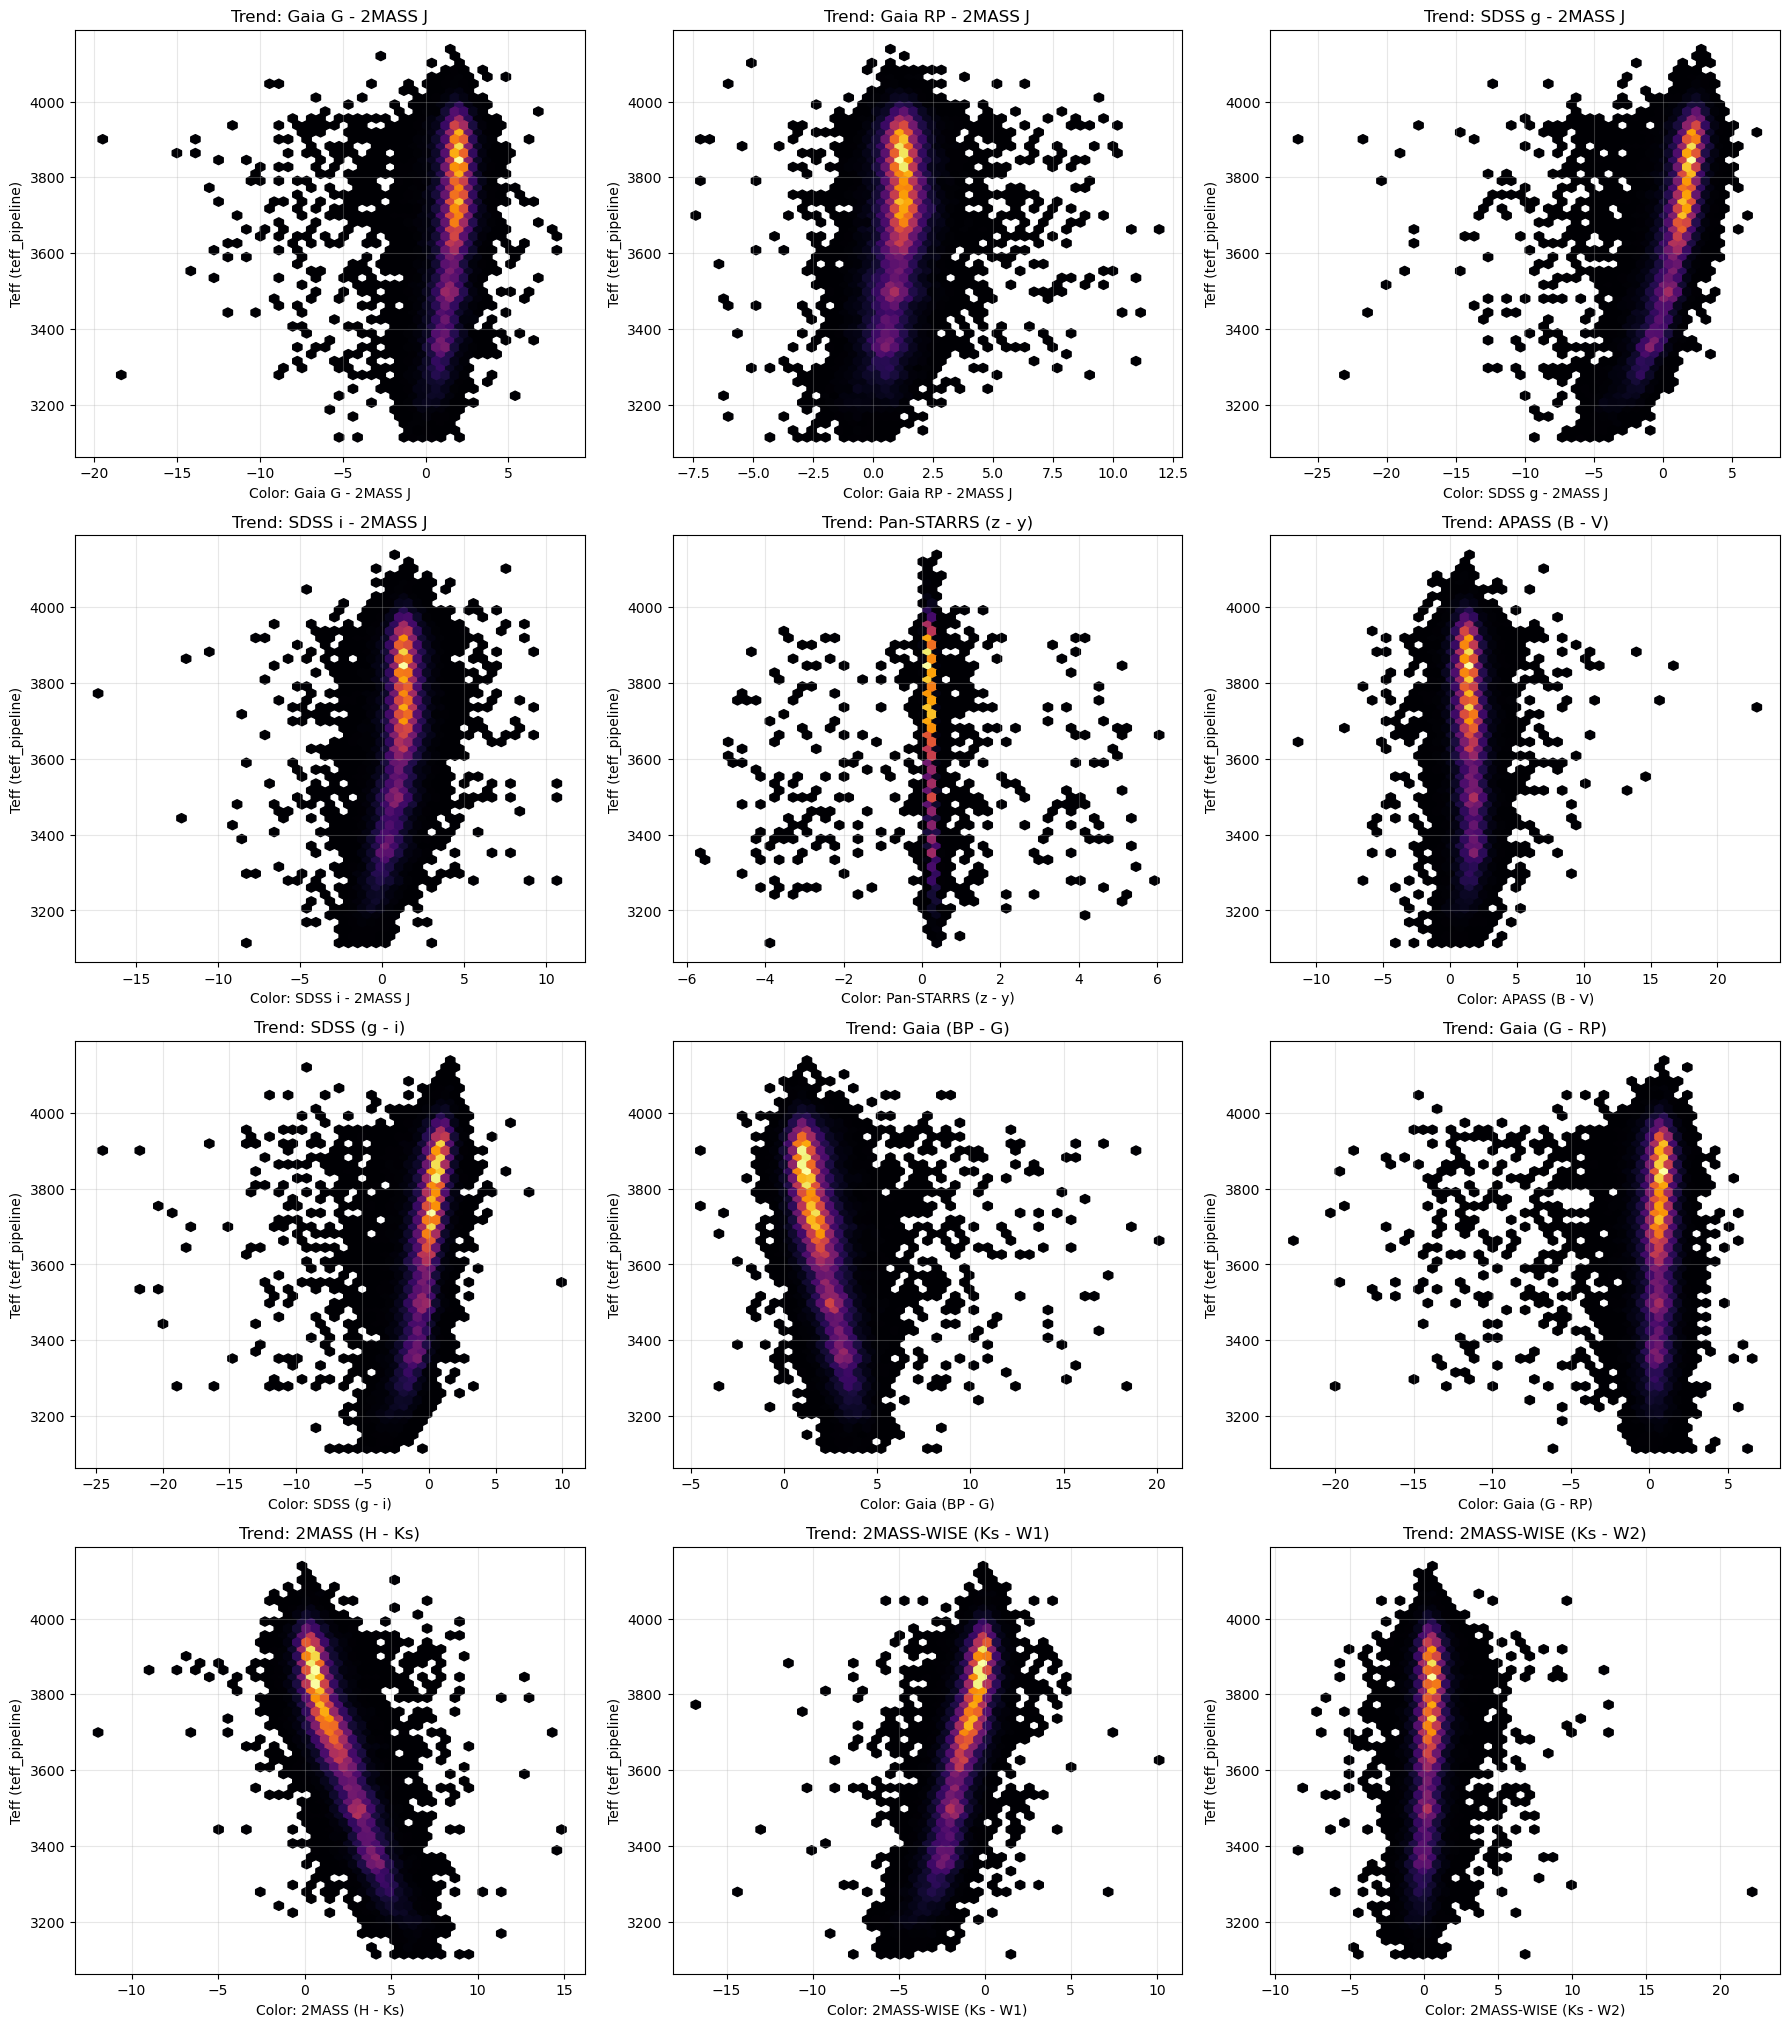

In [15]:
plot_all_colors(df_final, color_combinations, teff_col='teff_pipeline')

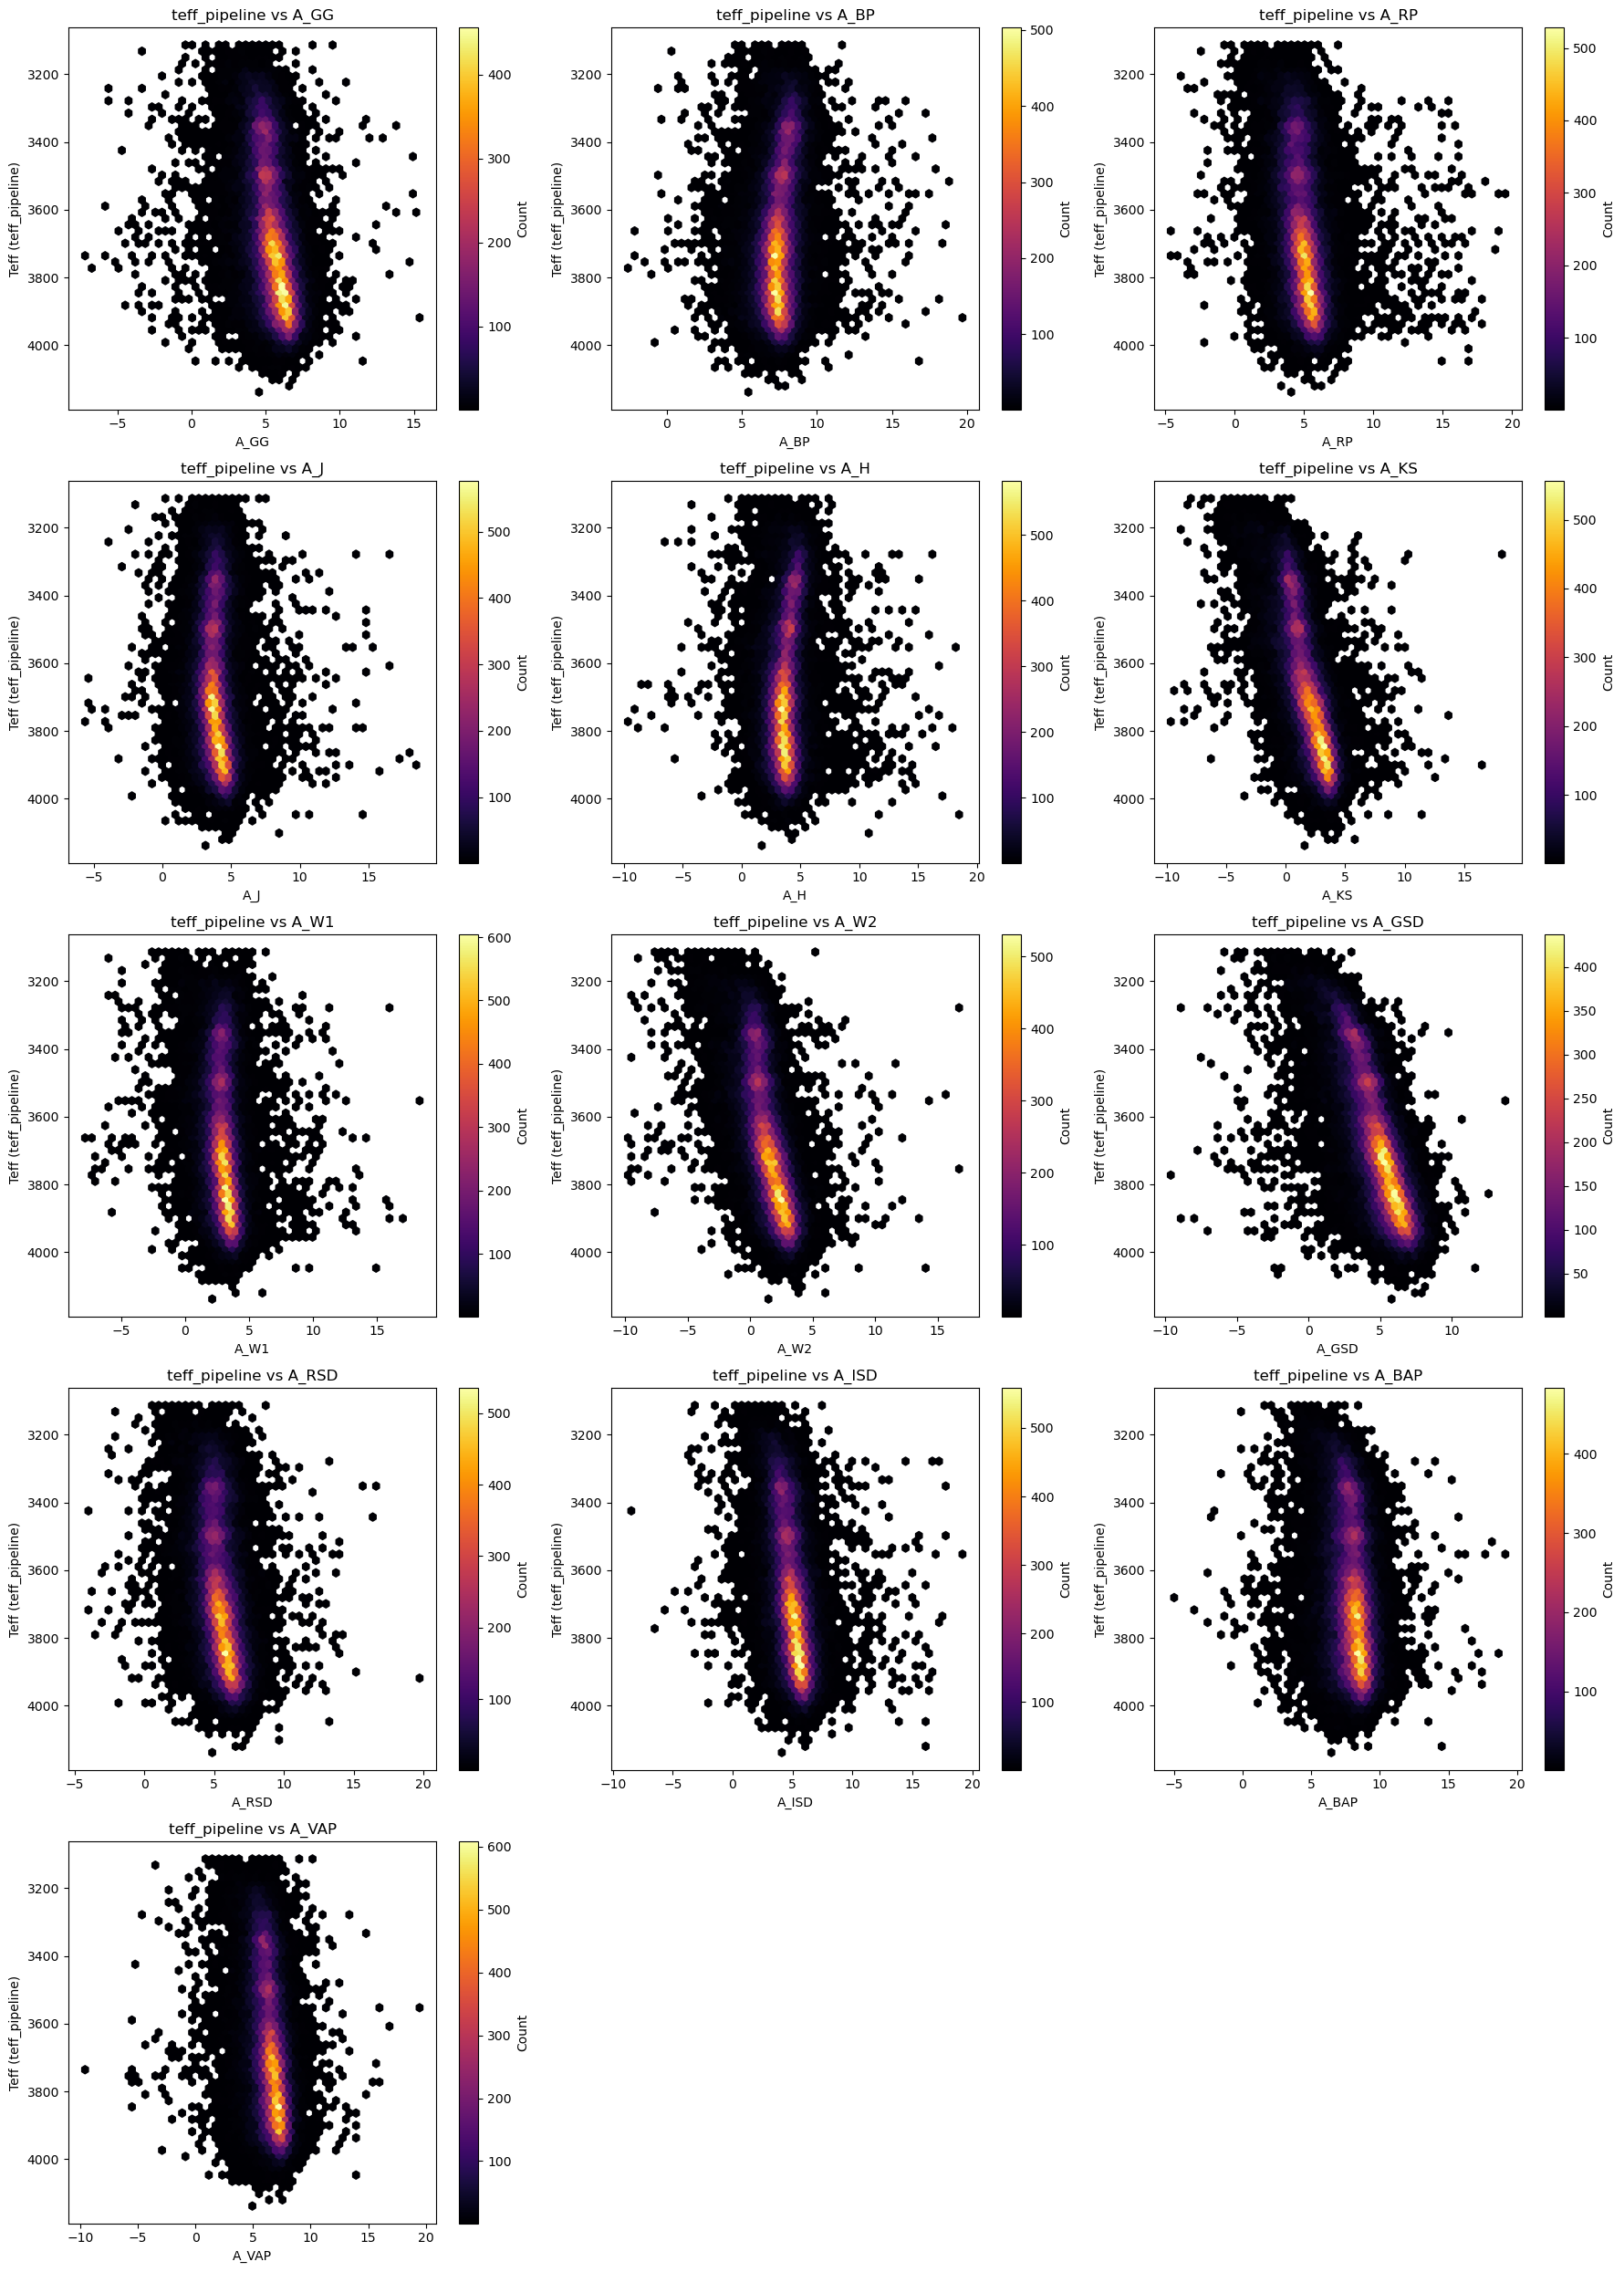

In [ ]:
import matplotlib.pyplot as plt

def plot_teff_vac_vs_absolute_magnitudes(df, magnitude_columns, teff_col='teff_vac'):
    num_plots = len(magnitude_columns)
    rows = (num_plots // 3) + 1
    plt.figure(figsize=(18, 5 * rows))

    for i, mag_col in enumerate(magnitude_columns):
        if mag_col not in df.columns:
            print(f"Skipping {mag_col}: Column not found in DataFrame.")
            continue

        plt.subplot(rows, 3, i + 1)

        # Filter for valid values
        mask = df[mag_col].notnull() & df[teff_col].notnull()
        valid_data = df[mask]

        if len(valid_data) == 0:
            print(f"Skipping {mag_col}: No valid data.")
            continue

        x_magnitude = valid_data[mag_col]
        y_teff = valid_data[teff_col]

        # Plot
        plt.hexbin(x_magnitude, y_teff, gridsize=50, cmap='inferno', mincnt=1)
        plt.colorbar(label='Count')
        plt.xlabel(f'{mag_col}')
        plt.ylabel(f'Teff ({teff_col})')
        plt.title(f'{teff_col} vs {mag_col}')
        plt.gca().invert_yaxis()  # Convention: Hotter stars on top

    plt.tight_layout()
    plt.show()

# Define the list of absolute magnitude columns to plot
absolute_magnitude_columns = [
    'A_GG', 'A_BP', 'A_RP',
    'A_J', 'A_H', 'A_KS',
    'A_W1', 'A_W2',
    'A_GSD', 'A_RSD', 'A_ISD',
    'A_BAP', 'A_VAP'
]

# Run the plot function
plot_teff_vac_vs_absolute_magnitudes(df_final, absolute_magnitude_columns, teff_col='teff_pipeline')

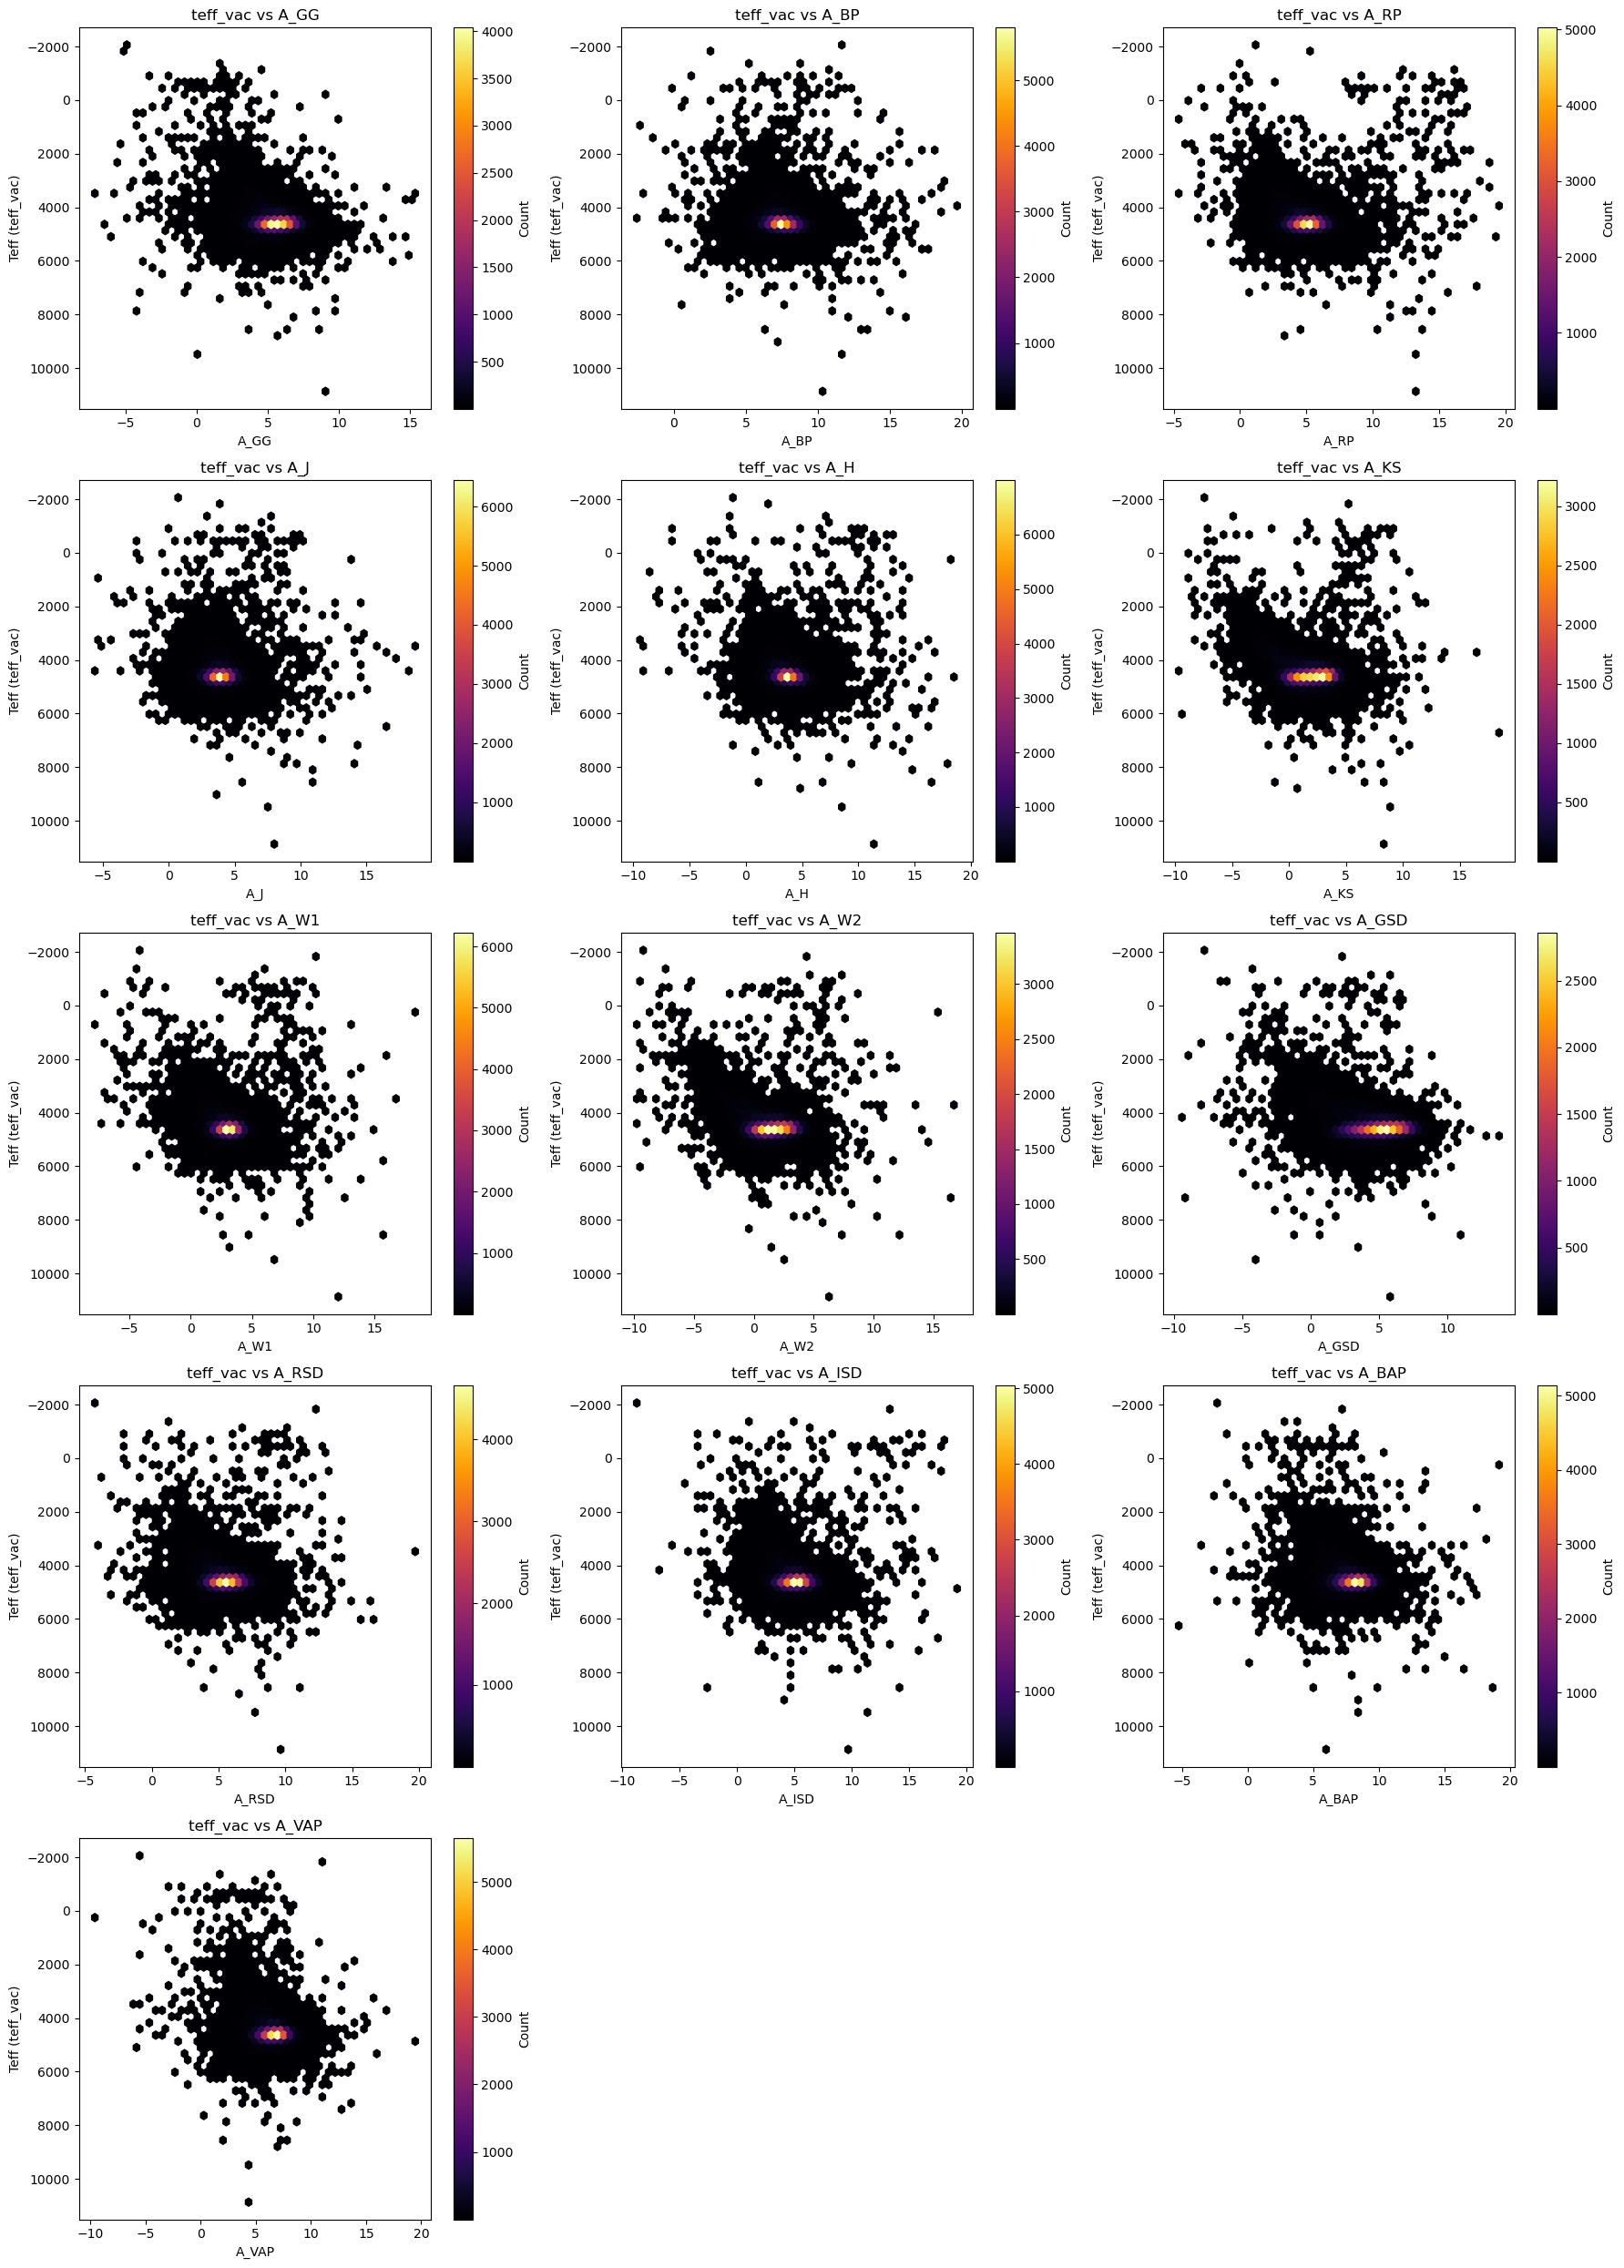

In [19]:
plot_teff_vac_vs_absolute_magnitudes(df_final, absolute_magnitude_columns, teff_col='teff_vac')